# Chronic Kidney Disease Presence Prediction — Exploratory Data Analysis

> **For research and educational purposes only.** This notebook explores a historical
> public dataset. Nothing here is a medical diagnosis or medical advice.

This notebook is a thin view over the reusable `ml` package. Re-run
`python -m ml.eda.run kidney` to regenerate `reports/kidney/`.


In [1]:
import sys, os
# Make the repository root importable when the kernel starts in notebooks/.
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)  # so relative paths (reports/, data/) resolve from the repo root

import pandas as pd
pd.set_option("display.max_columns", 60)

from ml.data.loaders import load_kidney
from ml.eda import profile

X, y, spec = load_kidney()
print(spec.notes)


Target: 'class' text {'ckd','notckd'} mapped to {1,0}. Extensive missing values across most columns; imputed inside the model pipeline. Numeric columns pcv/wbcc/rbcc were stored as text (stray tab characters) and coerced to numbers. Nominal yes/no and normal/abnormal columns mapped to 0/1. 'sg','al','su' are ordinal clinical scales kept as numeric. n=400.


## 1. Dataset overview

In [2]:
profile.dataset_overview(X, y, spec)

{'disease': 'kidney',
 'n_rows': 400,
 'n_features': 24,
 'n_numeric': 14,
 'n_categorical': 0,
 'n_binary': 10,
 'target': 'ckd_present',
 'target_positive_meaning': "Target: 'class' text {'ckd','notckd'} mapped to {1,0}",
 'total_missing_cells': 1012,
 'rows_with_any_missing': 242,
 'duplicate_rows': 0,
 'memory_mb': np.float64(0.077)}

## 2. Target distribution

In [3]:
display(profile.target_distribution(y))
print("class-imbalance ratio (majority / minority):", profile.class_imbalance_ratio(y))


,class,count,proportion
0,0,150,0.375
1,1,250,0.625


class-imbalance ratio (majority / minority): 1.67


## 3. Missing values

In [4]:
profile.missing_value_table(X)

,column,dtype,n_missing,pct_missing,n_unique
0,rbc,float64,152,38.00,2
1,rbcc,float64,131,32.75,45
2,wbcc,float64,106,26.50,89
3,pot,float64,88,22.00,40
4,sod,float64,87,21.75,34
5,pcv,float64,71,17.75,42
6,pc,float64,65,16.25,2
7,hemo,float64,52,13.00,115
8,su,float64,49,12.25,6
9,sg,float64,47,11.75,5


## 4. Numeric feature summary

In [5]:
profile.numeric_summary(X, spec)

,count,mean,std,min,25%,50%,75%,max,missing,skew
age,391.0,51.483,17.170,2.000,42.00,55.00,64.50,90.000,9,-0.668
bp,388.0,76.469,13.684,50.000,70.00,80.00,80.00,180.000,12,1.605
sg,353.0,1.017,0.006,1.005,1.01,1.02,1.02,1.025,47,-0.172
al,354.0,1.017,1.353,0.000,0.00,0.00,2.00,5.000,46,0.998
su,351.0,0.450,1.099,0.000,0.00,0.00,0.00,5.000,49,2.464
bgr,356.0,148.037,79.282,22.000,99.00,121.00,163.00,490.000,44,2.011
bu,381.0,57.426,50.503,1.500,27.00,42.00,66.00,391.000,19,2.634
sc,383.0,3.072,5.741,0.400,0.90,1.30,2.80,76.000,17,7.510
sod,313.0,137.529,10.409,4.500,135.00,138.00,142.00,163.000,87,-6.997
pot,312.0,4.627,3.194,2.500,3.80,4.40,4.90,47.000,88,11.583


## 5. Outlier scan (IQR fences — diagnostic only, nothing removed)

In [6]:
profile.outlier_scan(X, spec)

,column,q1,q3,iqr_lower_fence,iqr_upper_fence,n_outliers,pct_outliers,min,max
0,age,42.00,64.50,8.250,98.250,10,2.56,2.000,90.000
1,bp,70.00,80.00,55.000,95.000,36,9.28,50.000,180.000
2,sg,1.01,1.02,0.995,1.035,0,0.00,1.005,1.025
3,al,0.00,2.00,-3.000,5.000,0,0.00,0.000,5.000
4,su,0.00,0.00,0.000,0.000,61,17.38,0.000,5.000
5,bgr,99.00,163.00,3.000,259.000,34,9.55,22.000,490.000
6,bu,27.00,66.00,-31.500,124.500,38,9.97,1.500,391.000
7,sc,0.90,2.80,-1.950,5.650,51,13.32,0.400,76.000
8,sod,135.00,142.00,124.500,152.500,16,5.11,4.500,163.000
9,pot,3.80,4.90,2.150,6.550,4,1.28,2.500,47.000


## 6. Numeric feature / target association (descriptive)

In [7]:
profile.target_feature_association(X, y, spec)

,feature,corr_with_target
0,hemo,-0.769
1,pcv,-0.741
2,sg,-0.732
3,rbcc,-0.699
4,al,0.627
5,bgr,0.420
6,bu,0.381
7,sod,-0.376
8,su,0.344
9,sc,0.300


## 7. Categorical / binary breakdown

In [8]:
cs = profile.categorical_summary(X, spec)
for name, table in cs.items():
    print(f"--- {name} ---")
    display(table)


--- rbc ---


,value,count,proportion
0,0.0,201,0.5025
1,nan,152,0.3800
2,1.0,47,0.1175


--- pc ---


,value,count,proportion
0,0.0,259,0.6475
1,1.0,76,0.1900
2,nan,65,0.1625


--- pcc ---


...

,value,count,proportion
0,0.0,317,0.7925
1,1.0,82,0.2050
2,nan,1,0.0025


--- pe ---


,value,count,proportion
0,0.0,323,0.8075
1,1.0,76,0.1900
2,nan,1,0.0025


--- ane ---


,value,count,proportion
0,0.0,339,0.8475
1,1.0,60,0.1500
2,nan,1,0.0025


## 8. Figures

Generated into `reports/kidney/figures/`.

categorical_positive_rate.png


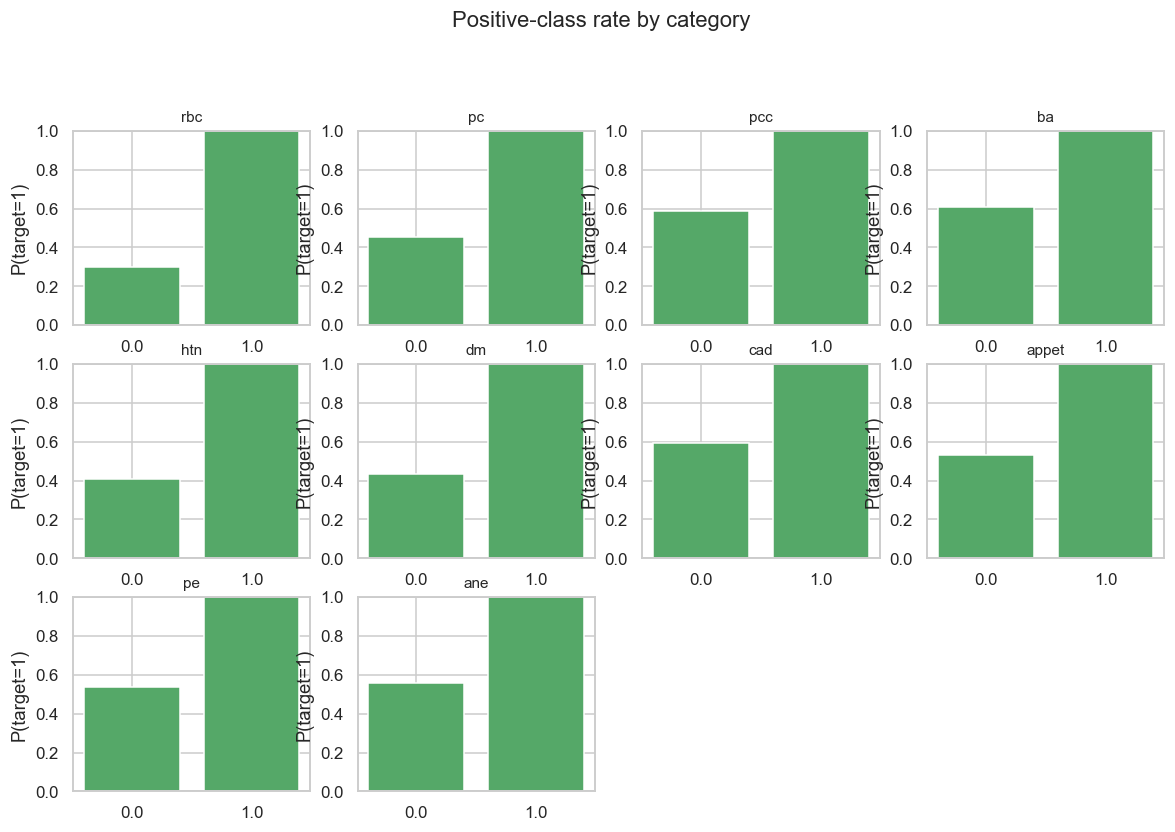

correlation_heatmap.png


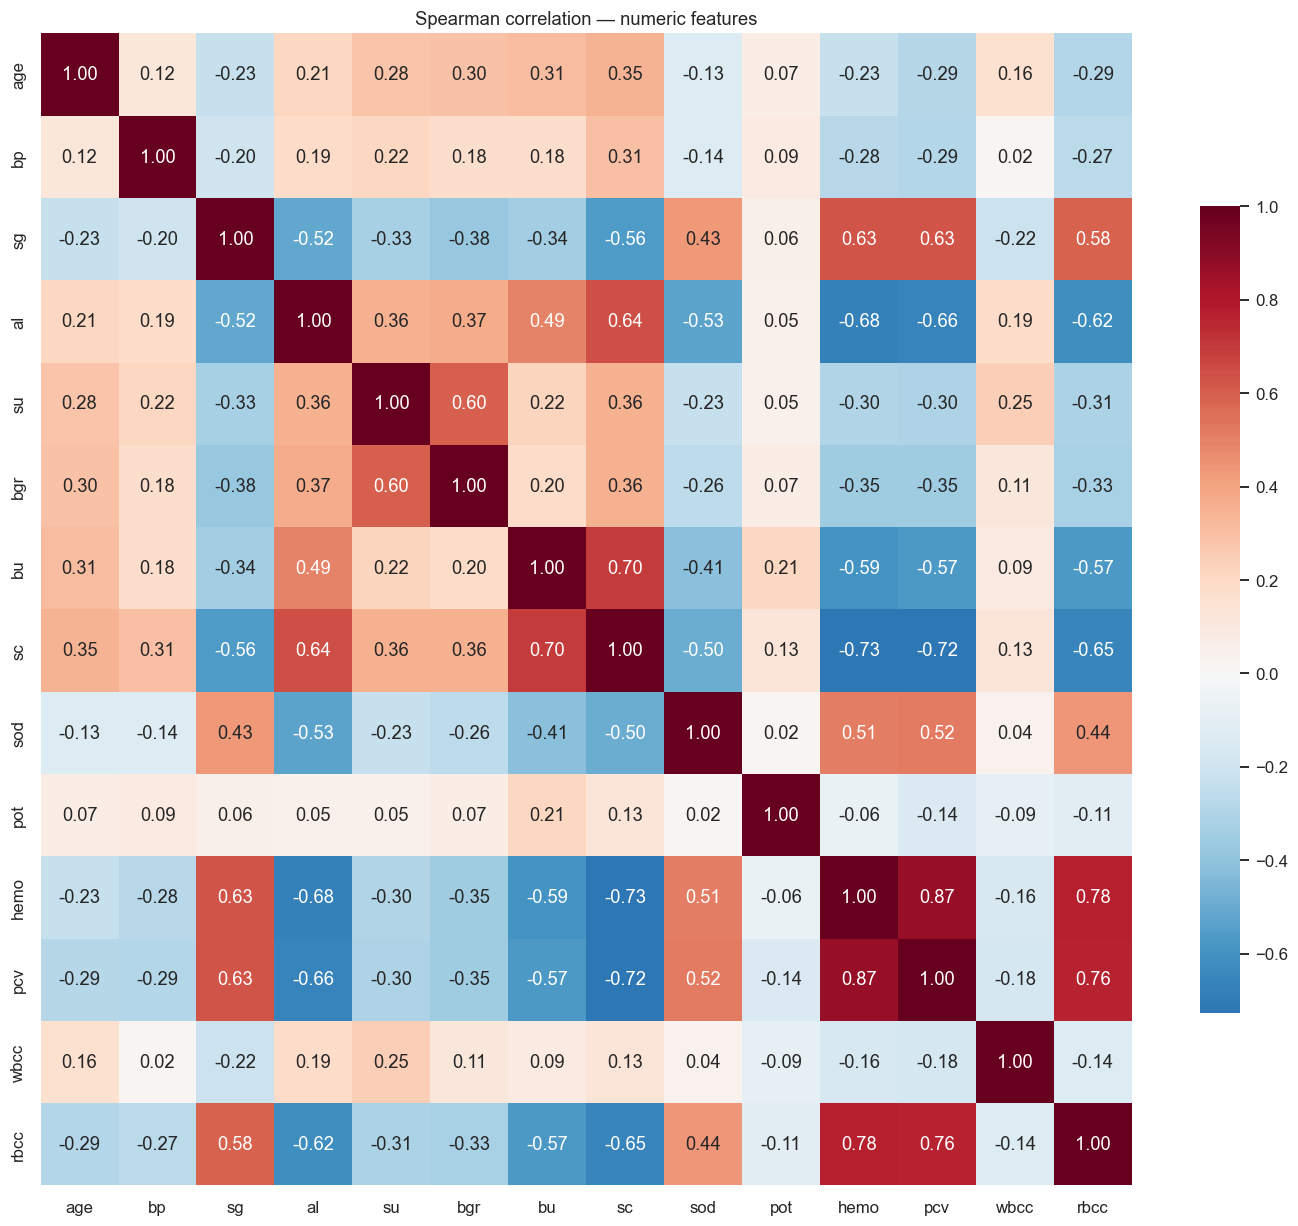

missingness.png


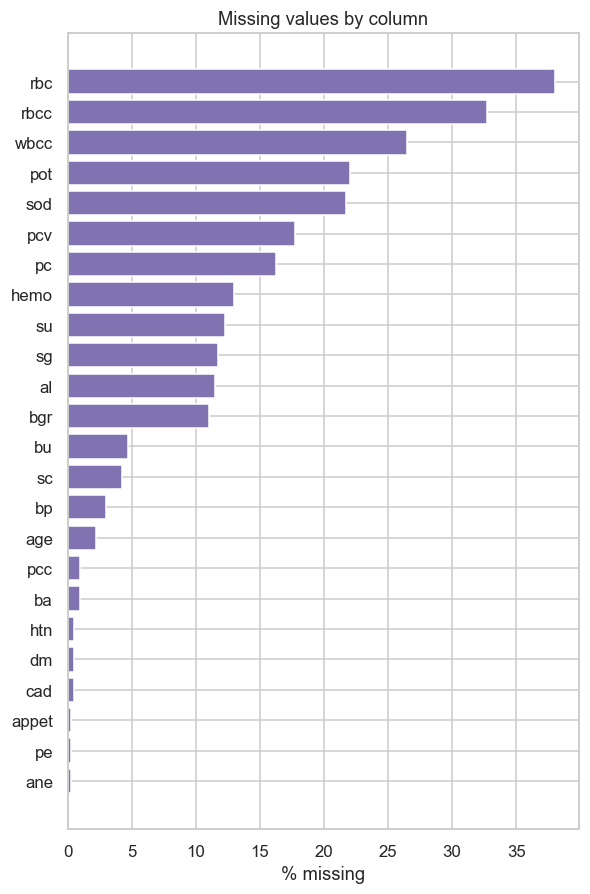

numeric_boxplots_by_target.png


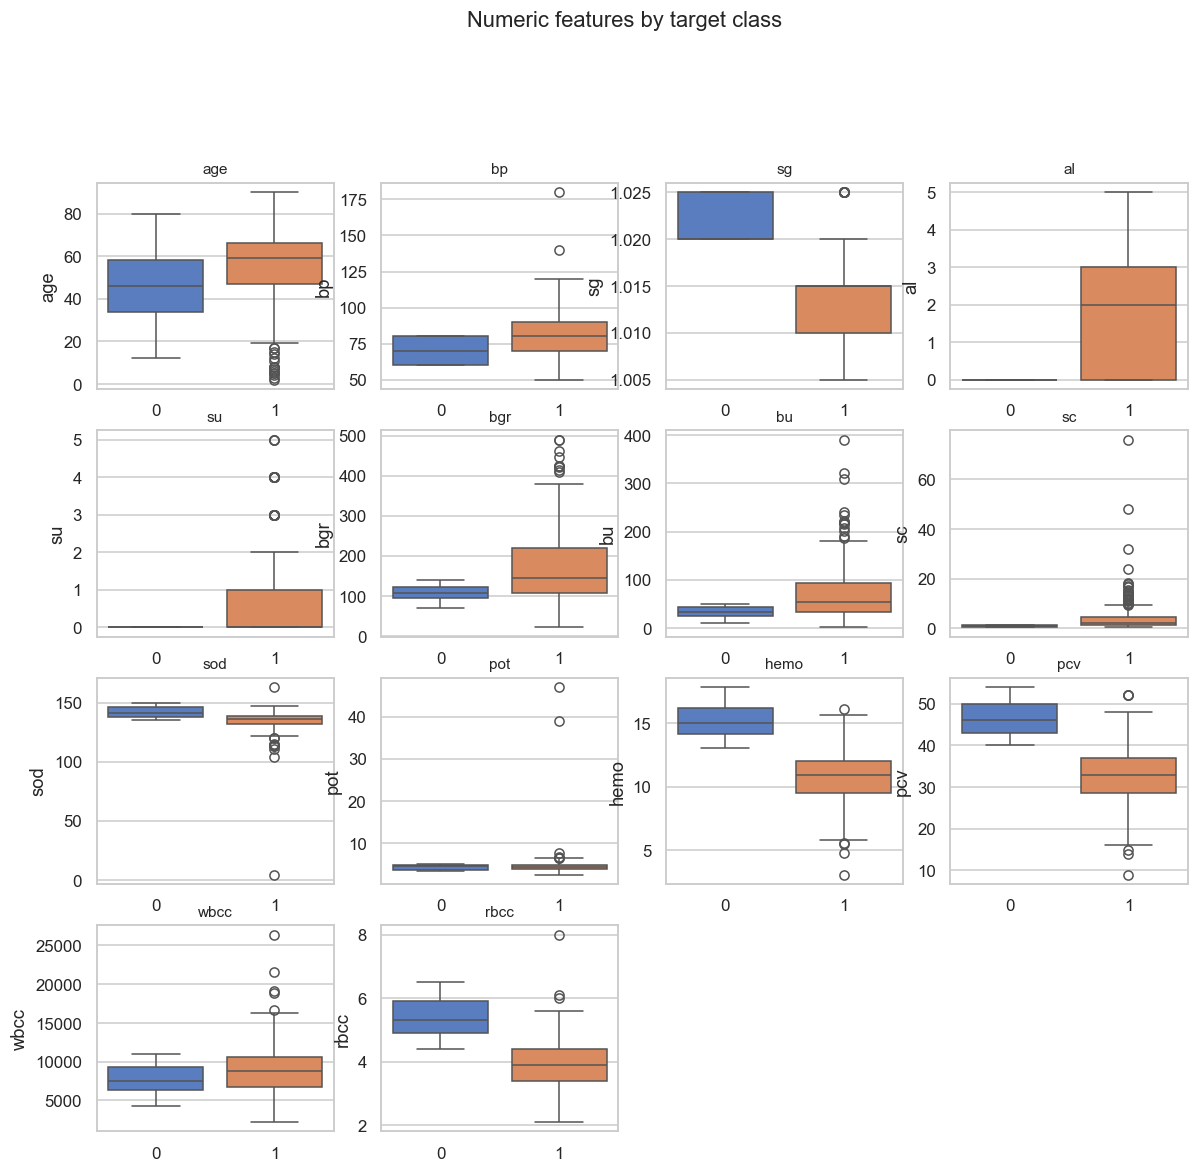

numeric_histograms.png


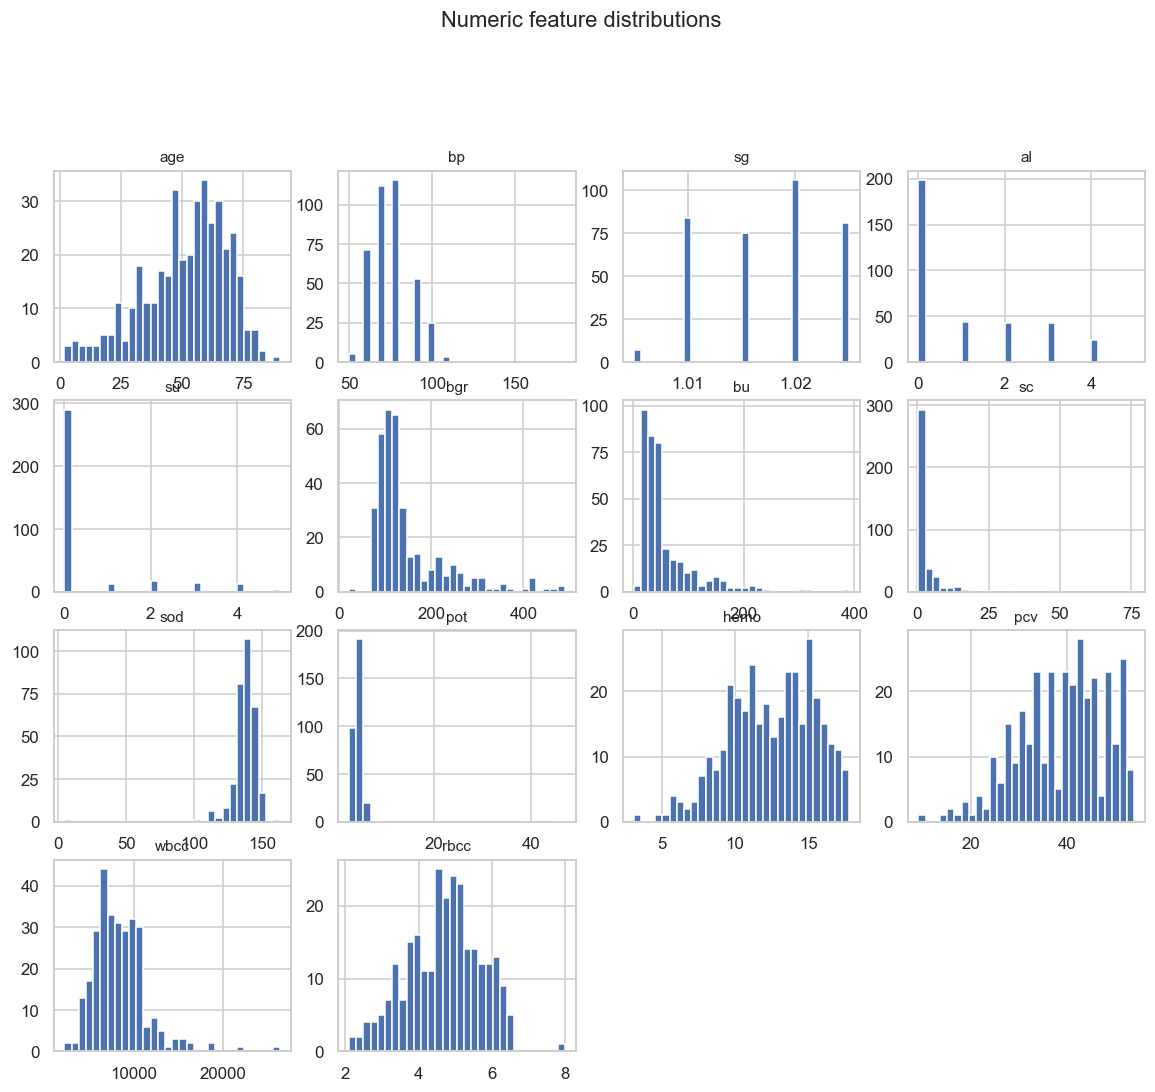

target_distribution.png


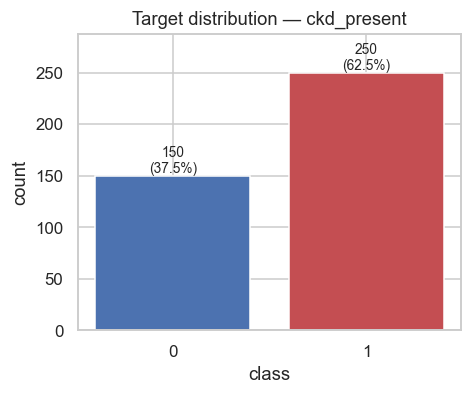

In [9]:
from pathlib import Path
from IPython.display import Image, display
from ml.eda.run import run_eda

run_eda("kidney")
fig_dir = Path("reports") / "kidney" / "figures"
for png in sorted(fig_dir.glob("*.png")):
    print(png.name)
    display(Image(filename=str(png)))


## 9. Written summaries

- Target definition + feature dictionary: [`reports/kidney/TARGET.md`](../reports/kidney/TARGET.md)
- EDA summary: [`reports/kidney/EDA.md`](../reports/kidney/EDA.md)
